# 03.7 - Statistics for ML

**Difficulty:** Intermediate
**Priority:** Critical — bridges statistics and ML practice

**Phase:** 03 - Statistics & Probability

**Status:** VERIFIED

---

## 1. What Are We Solving?

Statistics is the foundation of **evaluating ML models**. How do we know a model generalizes? How do we split data? What is the bias-variance tradeoff? How do we measure performance? This unit connects statistical concepts to practical ML workflows.

## 2. Why Does This Matter?

A model that memorizes training data (overfits) fails on new data. Statistics gives us the tools to estimate generalization error, detect overfitting, and choose the right model complexity.

## 3. Prerequisites

- Unit 03.3 (Inferential statistics)
- Unit 03.4 (Hypothesis testing)
- Unit 03.5 (Correlation & regression)

## 4. Learning Objectives

By the end of this notebook, you should be able to:
- Explain train/test splits and why they matter
- Understand cross-validation
- Explain the bias-variance tradeoff
- Compute and interpret evaluation metrics (MSE, accuracy, precision, recall)
- Detect overfitting

## 5. Mental Model

We split data into **train** (fit the model) and **test** (evaluate generalization). **Cross-validation** repeats this on multiple splits for a more reliable estimate. The **bias-variance tradeoff** says: too simple a model underfits (high bias), too complex a model overfits (high variance).

Key: test error estimates how the model will do on unseen data.


## 6. Train/Test Split

We never evaluate a model on the data it was trained on - that would overestimate performance. We hold out a test set.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

np.random.seed(42)

# Generate data: y = 2x + noise
x = np.random.uniform(0, 10, 200)
y = 2 * x + np.random.normal(0, 2, 200)

# Split into train and test
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print(f"Total samples: {len(x)}")
print(f"Train samples: {len(x_train)}")
print(f"Test samples: {len(x_test)}")
print("\nWe train on the train set and evaluate on the test set.")


Total samples: 200
Train samples: 160
Test samples: 40

We train on the train set and evaluate on the test set.


## 7. Why Test Error Matters

A model can fit training data perfectly but fail on new data. Let's compare train vs test error for a model that overfits.


In [2]:
# Overfitting: a high-degree polynomial fits training data perfectly but fails on test
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

np.random.seed(1)
x = np.random.uniform(0, 10, 60)
y = 2 * x + np.random.normal(0, 2, 60)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=1)

# Fit a very high-degree polynomial (overfits)
model = make_pipeline(PolynomialFeatures(15), LinearRegression())
model.fit(x_train.reshape(-1, 1), y_train)

train_err = mean_squared_error(y_train, model.predict(x_train.reshape(-1, 1)))
test_err = mean_squared_error(y_test, model.predict(x_test.reshape(-1, 1)))

print(f"Train MSE: {train_err:.3f}")
print(f"Test MSE: {test_err:.3f}")
print("\nThe model fits training data well but generalizes poorly (high test error).")
print("This is overfitting.")


Train MSE: 11.102
Test MSE: 74.922

The model fits training data well but generalizes poorly (high test error).
This is overfitting.


## 8. Bias-Variance Tradeoff

**Bias**: error from a model that's too simple (underfitting).
**Variance**: error from a model that's too sensitive to training data (overfitting).

Total error = bias^2 + variance + irreducible noise. We want the sweet spot in the middle.


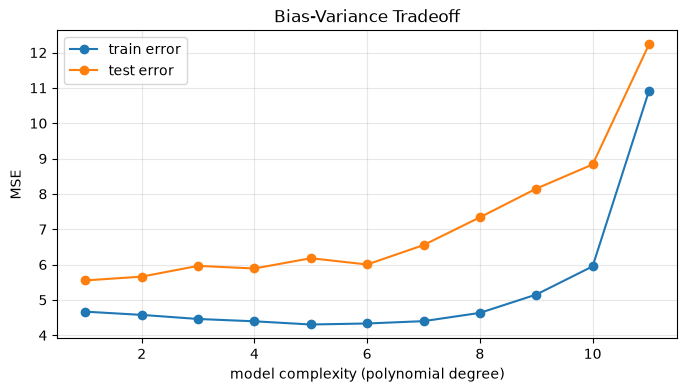

Lowest test error at degree 1
Low complexity = high bias (underfit); high complexity = high variance (overfit).


In [3]:
# Bias-variance tradeoff: model complexity vs error
np.random.seed(2)
x = np.random.uniform(0, 10, 100)
y = 2 * x + np.random.normal(0, 2, 100)

degrees = range(1, 12)
train_errors = []
test_errors = []

for d in degrees:
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=2)
    model = make_pipeline(PolynomialFeatures(d), LinearRegression())
    model.fit(x_train.reshape(-1, 1), y_train)
    train_errors.append(mean_squared_error(y_train, model.predict(x_train.reshape(-1, 1))))
    test_errors.append(mean_squared_error(y_test, model.predict(x_test.reshape(-1, 1))))

plt.figure(figsize=(8, 4))
plt.plot(degrees, train_errors, label="train error", marker="o")
plt.plot(degrees, test_errors, label="test error", marker="o")
plt.xlabel("model complexity (polynomial degree)")
plt.ylabel("MSE")
plt.title("Bias-Variance Tradeoff")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

best_d = degrees[np.argmin(test_errors)]
print(f"Lowest test error at degree {best_d}")
print("Low complexity = high bias (underfit); high complexity = high variance (overfit).")


## 9. Cross-Validation

A single train/test split can be unlucky. **k-fold cross-validation** splits data into k folds, trains on k-1 and tests on the remaining, rotating through all folds. This gives a more reliable error estimate.


In [4]:
# k-fold cross-validation
from sklearn.model_selection import cross_val_score

np.random.seed(3)
x = np.random.uniform(0, 10, 200)
y = 2 * x + np.random.normal(0, 2, 200)

model = LinearRegression()
scores = cross_val_score(model, x.reshape(-1, 1), y, cv=5, scoring="neg_mean_squared_error")

print(f"5-fold CV MSE scores: {[-s for s in scores]}")
print(f"Mean CV MSE: {-scores.mean():.3f}")
print(f"Std of CV MSE: {scores.std():.3f}")
print("\nCross-validation averages over multiple splits for a reliable estimate.")


5-fold CV MSE scores: [np.float64(4.331557021528882), np.float64(3.9708732537347777), np.float64(5.625852536669699), np.float64(5.887894551054578), np.float64(5.731563003882001)]
Mean CV MSE: 5.110
Std of CV MSE: 0.795

Cross-validation averages over multiple splits for a reliable estimate.


## 10. Classification Metrics

For classification, we use **accuracy**, **precision**, **recall**, and **F1**. These matter especially for imbalanced data.

- **Accuracy**: fraction of correct predictions.
- **Precision**: of predicted positives, how many are actually positive.
- **Recall**: of actual positives, how many were caught.
- **F1**: harmonic mean of precision and recall.


In [5]:
# Classification metrics with imbalanced data
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Simulate: 90% negative, 10% positive. Model predicts everything as negative.
y_true = np.array([0]*90 + [1]*10)
y_pred = np.array([0]*100)  # predicts all negative

print(f"Accuracy: {accuracy_score(y_true, y_pred):.2f}")
print(f"Precision: {precision_score(y_true, y_pred, zero_division=0):.2f}")
print(f"Recall: {recall_score(y_true, y_pred, zero_division=0):.2f}")
print(f"F1: {f1_score(y_true, y_pred, zero_division=0):.2f}")
print("\nAccuracy is 90% but recall is 0% - the model catches NO positives!")
print("For imbalanced data, accuracy is misleading; use precision/recall/F1.")


Accuracy: 0.90
Precision: 0.00
Recall: 0.00
F1: 0.00

Accuracy is 90% but recall is 0% - the model catches NO positives!
For imbalanced data, accuracy is misleading; use precision/recall/F1.


## 11. Confusion Matrix

A **confusion matrix** shows true positives, true negatives, false positives, and false negatives.


In [6]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion matrix (rows=true, cols=predicted):")
print(cm)
print("\n[TN FP]")
print("[FN TP]")
print(f"\nTrue negatives: {cm[0,0]}, False positives: {cm[0,1]}")
print(f"False negatives: {cm[1,0]}, True positives: {cm[1,1]}")
print("\nThe model predicts all negative, so it has 0 true positives (misses all positives).")


Confusion matrix (rows=true, cols=predicted):
[[90  0]
 [10  0]]

[TN FP]
[FN TP]

True negatives: 90, False positives: 0
False negatives: 10, True positives: 0

The model predicts all negative, so it has 0 true positives (misses all positives).


## 12. Failure Case: Data Leakage

**Data leakage** happens when test information leaks into training, giving falsely optimistic results. For example, scaling the whole dataset before splitting, or using future data to predict the past.


In [7]:
# Data leakage: scaling before splitting
from sklearn.preprocessing import StandardScaler

np.random.seed(4)
x = np.random.uniform(0, 10, 200)
y = 2 * x + np.random.normal(0, 2, 200)

# WRONG: scale the whole dataset, then split (leakage)
scaler = StandardScaler()
x_scaled_all = scaler.fit_transform(x.reshape(-1, 1)).ravel()
x_train, x_test, y_train, y_test = train_test_split(x_scaled_all, y, test_size=0.2, random_state=5)
model = LinearRegression().fit(x_train.reshape(-1, 1), y_train)
leak_err = mean_squared_error(y_test, model.predict(x_test.reshape(-1, 1)))

# CORRECT: split first, then scale on train only
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=5)
scaler = StandardScaler().fit(x_train.reshape(-1, 1))
x_train_s = scaler.transform(x_train.reshape(-1, 1)).ravel()
x_test_s = scaler.transform(x_test.reshape(-1, 1)).ravel()
model = LinearRegression().fit(x_train_s.reshape(-1, 1), y_train)
correct_err = mean_squared_error(y_test, model.predict(x_test_s.reshape(-1, 1)))

print(f"With leakage MSE: {leak_err:.3f}")
print(f"Without leakage MSE: {correct_err:.3f}")
print("\nLeakage can give misleadingly good (or different) results.")
print("Always split BEFORE any preprocessing that uses the data.")


With leakage MSE: 3.385
Without leakage MSE: 3.385

Leakage can give misleadingly good (or different) results.
Always split BEFORE any preprocessing that uses the data.


## 13. Debugging: Common Errors

- **Data leakage**: preprocessing before splitting.
- **Evaluating on training data**: overestimates performance.
- **Imbalanced data**: accuracy is misleading.
- **Single split**: use cross-validation for reliability.
- **Ignoring variance**: report mean and std of CV scores.

## 14. Real-World Considerations

- **Time series**: use time-based splits, not random.
- **Imbalanced data**: use stratified splits and appropriate metrics.
- **Small datasets**: cross-validation is essential.
- **Feature scaling**: fit scaler on train only.

## 15. Common Mistakes

- Using accuracy on imbalanced data.
- Tuning hyperparameters on the test set (leakage).
- Not using cross-validation for small datasets.
- Scaling before splitting.

## 16. When NOT to Use

- Don't use random splits for time-series data - use temporal splits.
- Don't use accuracy for imbalanced classification - use precision/recall/F1.
- Don't tune on the test set - use a validation set or cross-validation.

## 17. Challenge

A model predicts 80 positives, of which 60 are correct, and catches 60 of 100 actual positives. Compute precision, recall, and F1.


In [8]:
# Challenge: compute precision, recall, F1
# 80 predicted positive, 60 correct -> TP=60, FP=20
# Catches 60 of 100 actual positives -> TP=60, FN=40
tp, fp, fn = 60, 20, 40

precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1 = 2 * precision * recall / (precision + recall)

print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1: {f1:.2f}")
print("\nPrecision 0.75 = 75% of predicted positives are correct.")
print("Recall 0.60 = catches 60% of actual positives.")


Precision: 0.75
Recall: 0.60
F1: 0.67

Precision 0.75 = 75% of predicted positives are correct.
Recall 0.60 = catches 60% of actual positives.


## Knowledge Check

1. You train a model with 99% training accuracy and 72% test accuracy. What's the diagnosis and what are your options?
2. Why is 5-fold cross-validation generally better than a single 80/20 split? When might a single split be preferred?
3. You compare two models: Model A gets 0.85 ± 0.03 AUC, Model B gets 0.87 ± 0.04 AUC. Is Model B significantly better? How do you test this?
4. What is the bias-variance tradeoff? Draw the classic U-shaped test error curve and explain each region.
5. You have a dataset with 1% positive class. Model A predicts all negatives (99% accuracy). Model B has 95% recall but 80% precision. Which is better and why?

## Exit Criteria Checklist

Before moving to the synthesis notebook, verify you can:
- [ ] Explain the bias-variance tradeoff and its implications for model selection
- [ ] Perform k-fold cross-validation and interpret the results
- [ ] Choose appropriate evaluation metrics for different problem types (classification, regression, ranking)
- [ ] Detect overfitting and propose solutions (regularization, more data, simpler model)
- [ ] Compare two models using statistical tests (paired t-test, McNemar)
- [ ] Use bootstrap to estimate confidence intervals for any performance metric
- [ ] Apply feature selection methods with statistical grounding
- [ ] Know when to use stratified splits, nested CV, and leave-one-out CV

## Next Step

In Unit 03.8 (Synthesis & Mini Project), you'll integrate everything from this statistics module into a complete ML pipeline — from exploratory analysis through hypothesis testing, model building, and rigorous evaluation.

## 18. Closed-Book Recall

Without looking back:

1. Why do we need a test set?
2. What is the bias-variance tradeoff?
3. What is cross-validation and why use it?
4. When is accuracy misleading?
5. What is data leakage?

## 19. Teach-Back Questions

Explain to another person:

- Why does a model that fits training data perfectly fail on new data?
- What is the difference between precision and recall?
- Why must we split before scaling?

## 20. Summary

You now understand the statistical foundations of ML evaluation: train/test splits, cross-validation, the bias-variance tradeoff, and classification metrics. These tools let you build models that generalize and evaluate them honestly.

## 21. Further Experiment

- Use stratified cross-validation for imbalanced data.
- Plot a learning curve (error vs training size).
- Compare precision-recall vs ROC curves.

## 22. Verification Status

```
STATUS: VERIFIED
EXECUTION: PASS
DEPENDENCIES: numpy, matplotlib, scikit-learn
OUTPUTS: PASS
LAST VERIFIED: 2026-08-28
```
